# Notebook 00 – Python & Scientific Computing Prerequisites

**Purpose:** A hands-on refresher of the Python tools we will use throughout the summer school — NumPy, Pandas, scikit-learn, and xarray — illustrated with space-physics-flavoured examples.

---

## Learning Objectives

By the end of this notebook you will be able to:

- Write clean, idiomatic Python using list comprehensions, functions, and common built-ins
- Manipulate numerical arrays efficiently with NumPy and understand broadcasting
- Load, clean, and explore tabular data with Pandas
- Set up a simple scikit-learn ML pipeline (feature scaling → model → evaluation)
- Describe what xarray adds on top of NumPy and why it matters for multi-dimensional mission data

---

## Background

Space physics data comes in many shapes: a one-dimensional time series of solar-wind speed, a 2-D spectrogram of particle energies or a 3-D ion distribution.  
The Python ecosystem has a layered answer to this variety:

| Layer | Tool | Role |
|-------|------|------|
| Raw arrays | **NumPy** | Fast math on homogeneous numerical data |
| Labelled tables | **Pandas** | Named columns, timestamps, missing values |
| ML models | **scikit-learn** | Preprocessing, models, evaluation |
| Labelled N-D arrays | **xarray** | Coordinates + metadata on multi-dimensional data |

We will build up through these layers in order.

In [1]:
# Standard imports we will use throughout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xarray as xr

%matplotlib inline

---

## Part 1 – Python Refresher

### 1.1 Data Types and Control Flow

Python's built-in containers — lists, dictionaries, tuples — are used constantly when wrangling metadata, configuration, and small datasets.  
The code below builds a small catalogue of space missions as a list of dictionaries: a pattern you will see throughout the school.

In [2]:
# A catalogue of missions we will use this week
missions = [
    {"name": "MMS",          "launch": 2015, "domain": "magnetosphere"},
    {"name": "Cluster",      "launch": 2000, "domain": "magnetosphere"},
    {"name": "THEMIS",       "launch": 2007, "domain": "magnetosphere"},
    {"name": "SOHO",         "launch": 1995, "domain": "heliosphere"},
    {"name": "SDO",          "launch": 2010, "domain": "heliosphere"},
    {"name": "Solar Orbiter","launch": 2020, "domain": "heliosphere"},
]

# List comprehension: filter to missions launched after 2005
recent = [m["name"] for m in missions if m["launch"] > 2005]
print("Recent missions:", recent)

# Dictionary grouping by domain
by_domain = {}
for m in missions:
    domain = m["domain"]
    by_domain.setdefault(domain, []).append(m["name"])

for domain, names in by_domain.items():
    print(f"  {domain}: {', '.join(names)}")

Recent missions: ['MMS', 'THEMIS', 'SDO', 'Solar Orbiter']
  magnetosphere: MMS, Cluster, THEMIS
  heliosphere: SOHO, SDO, Solar Orbiter


### 1.2 Functions and Docstrings

Throughout the school we will write utility functions to keep notebooks clean.  
The convention: one short docstring line, then the body. Type hints are optional but helpful.

In [3]:
def magnetic_pressure(B_nT: float) -> float:
    """Return magnetic pressure in nPa for a field magnitude given in nT."""
    mu0 = 4 * np.pi * 1e-7          # permeability of free space (SI)
    B_T = B_nT * 1e-9               # convert nT → T
    P_Pa = B_T**2 / (2 * mu0)       # B²/2μ₀ in Pa
    return P_Pa * 1e9               # convert Pa → nPa

# Quick sanity check: Earth's surface field ≈ 50 000 nT → ~1 nPa
print(f"Magnetic pressure at 50 000 nT: {magnetic_pressure(50_000):.3f} nPa")
print(f"Magnetopause field  ~  20 nT:   {magnetic_pressure(20):.4f} nPa")

Magnetic pressure at 50 000 nT: 994718.394 nPa
Magnetopause field  ~  20 nT:   0.1592 nPa


### Exercise 1.1

Write a function `dynamic_pressure(n_cc, v_km_s)` that computes solar-wind dynamic pressure $P_{dyn} = \frac{1}{2} m_p n v^2$ in nPa, where $n$ is proton number density in cm⁻³ and $v$ is speed in km s⁻¹.  
Check your result: a typical solar wind with $n = 5$ cm⁻³ and $v = 400$ km/s gives roughly 1.3 nPa.

In [4]:
def dynamic_pressure(n_cc: float, v_km_s: float) -> float:
    """Return solar-wind dynamic pressure in nPa."""
    # YOUR CODE HERE
    pass

# Uncomment to test:
# print(f"{dynamic_pressure(5, 400):.2f} nPa")

---

## Part 2 – NumPy

### Why NumPy?

A one-hour MMS burst dataset contains roughly 8 million magnetic-field samples. Looping over them in pure Python would take tens of seconds; NumPy's vectorised C routines do the same job in milliseconds. NumPy is the numerical backbone of everything else in our stack.

### 2.1 Creating Arrays — and Why NumPy is Fast

The claim that NumPy is faster than Python loops is easy to verify. Below we compute the magnetic field magnitude $|\mathbf{B}| = \sqrt{B_x^2 + B_y^2 + B_z^2}$ across one million time steps in two ways: first with an explicit Python `for` loop, then with a single NumPy call. Both produce the same answer; only the time differs.

The key reason: NumPy stores all values in a contiguous block of memory as native C `float64` values and executes the arithmetic in compiled C code without any Python interpreter overhead per element. The Python loop, by contrast, must look up, type-check, and unbox every number on every iteration.

In [11]:
import time
import math

# ── Shared setup ────────────────────────────────────────────────────────────
rng = np.random.default_rng(seed=42)
n_samples = 1_000_000   # 1 million samples — about 35 minutes of MMS burst data

# Generate the raw data as plain Python lists (Bx, By, Bz in nT)
Bx_list = rng.normal(10, 2, n_samples).tolist()
By_list = rng.normal(-5, 2, n_samples).tolist()
Bz_list = rng.normal( 3, 2, n_samples).tolist()

# ── Pure Python: compute |B| with a for-loop ─────────────────────────────
t0 = time.perf_counter()

B_mag_list = [
    math.sqrt(Bx_list[i]**2 + By_list[i]**2 + Bz_list[i]**2)
    for i in range(n_samples)
]

t_python = time.perf_counter() - t0
print(f"Pure Python loop : {t_python:.3f} s   |B| mean = {sum(B_mag_list)/len(B_mag_list):.4f} nT")

# ── NumPy: same calculation, vectorised ──────────────────────────────────
# Stack the three components into a (n_samples, 3) array first
B = np.column_stack([Bx_list, By_list, Bz_list])   # shape (1 000 000, 3)

t0 = time.perf_counter()

B_mag = np.linalg.norm(B, axis=1)                   # shape (1 000 000,)

t_numpy = time.perf_counter() - t0
print(f"NumPy vectorised : {t_numpy:.3f} s   |B| mean = {B_mag.mean():.4f} nT")

print(f"\nSpeedup: {t_python / t_numpy:.0f}×  faster with NumPy")

# ── Array metadata ────────────────────────────────────────────────────────
print(f"\nArray shape : {B.shape}   (rows = time steps, cols = Bx/By/Bz)")
print(f"Data type   : {B.dtype}")
print(f"Memory      : {B.nbytes / 1e6:.1f} MB")

# Trim to 1 000 samples for the rest of the notebook
n_samples = 1000
B = B[:1000]
B_mag = B_mag[:1000]
t = np.linspace(0, 600, 1000)

Pure Python loop : 0.171 s   |B| mean = 11.9209 nT
NumPy vectorised : 0.020 s   |B| mean = 11.9209 nT

Speedup: 8×  faster with NumPy

Array shape : (1000000, 3)   (rows = time steps, cols = Bx/By/Bz)
Data type   : float64
Memory      : 24.0 MB


### 2.2 Vectorised Operations, Broadcasting, and `keepdims`

**Vectorisation** means writing operations on whole arrays rather than element-by-element loops — NumPy handles the loop in compiled code. **Broadcasting** is the rule that lets arrays of different shapes be combined automatically.

One subtlety that catches many people: reduction operations like `mean`, `sum`, and `norm` **drop the axis they operate over** by default, changing the array shape. Always use `keepdims=True` to preserve the number of dimensions — the reduced axis becomes size-1 instead of disappearing. This makes the intended broadcast direction unambiguous, avoids the need for awkward `[:, np.newaxis]` workarounds, and keeps your shape reasoning consistent as arrays get passed between functions.

> **Note:** In most cases a missing `keepdims` will cause a `ValueError` that is easy to spot and fix. The more insidious situation is square arrays (e.g. a `(3, 3)` covariance or rotation matrix), where broadcasting can silently succeed but operate along the wrong axis, producing wrong numbers with no error. `keepdims` prevents both.

In [12]:
# ── Field magnitude |B| ──────────────────────────────────────────────────
# Without keepdims: the component axis disappears → shape (1000,)
B_mag_1d = np.linalg.norm(B, axis=1)             # shape (1000,)  ← 1-D

# With keepdims: the axis is kept as size-1 → shape (1000, 1)
B_mag = np.linalg.norm(B, axis=1, keepdims=True) # shape (1000, 1) ← still 2-D

print("Without keepdims:", B_mag_1d.shape)   # (1000,)
print("With    keepdims:", B_mag.shape)       # (1000, 1)

# ── Normalise each row to a unit vector: B_hat = B / |B| ─────────────────
# With keepdims=True the shape is (1000, 1), which broadcasts unambiguously
# against (1000, 3) along axis 1 — no extra bookkeeping needed.
B_hat = B / B_mag                            # (1000, 3) / (1000, 1) → (1000, 3)

print("\nUnit-vector magnitudes (min/max, should both be 1.0):",
      np.linalg.norm(B_hat, axis=1).min().round(10),
      np.linalg.norm(B_hat, axis=1).max().round(10))

# ── Broadcasting: subtract a per-component mean ──────────────────────────
# B.mean(axis=0, keepdims=True) → shape (1, 3); broadcasts cleanly against (1000, 3)
B_centered = B - B.mean(axis=0, keepdims=True)
print("Component means after centering:", B_centered.mean(axis=0).round(10))

# Flatten B_mag back to 1-D for plotting convenience
B_mag = B_mag.squeeze()   # (1000, 1) → (1000,)

Without keepdims: (1000,)
With    keepdims: (1000, 1)

Unit-vector magnitudes (min/max, should both be 1.0): 1.0 1.0
Component means after centering: [ 0. -0. -0.]


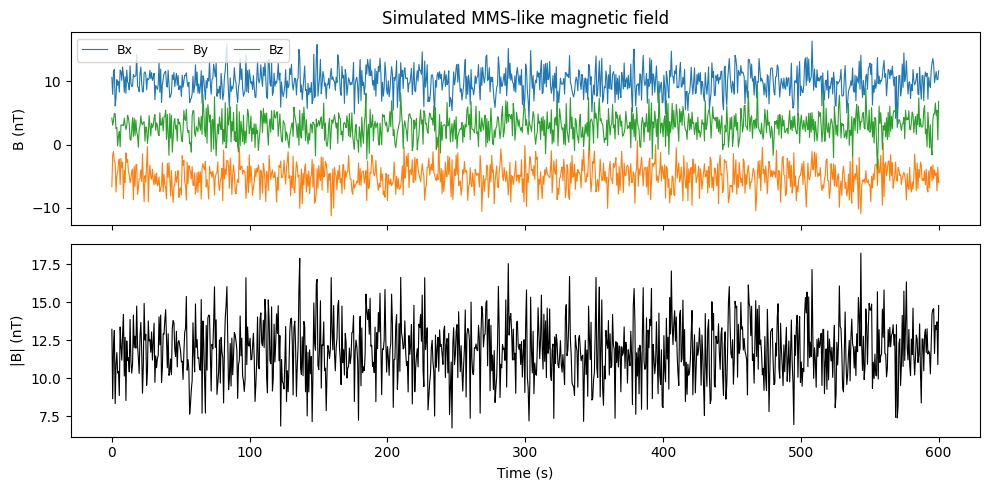

In [13]:
# Quick visualisation
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for i, comp in enumerate(["Bx", "By", "Bz"]):
    axes[0].plot(t, B[:, i], lw=0.8, label=comp)
axes[0].set_ylabel("B (nT)")
axes[0].legend(ncol=3, fontsize=9)
axes[0].set_title("Simulated MMS-like magnetic field")

axes[1].plot(t, B_mag, color="k", lw=0.8)
axes[1].set_ylabel("|B| (nT)")
axes[1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

### 2.3 Indexing, Slicing, and Boolean Masks

A very common pattern in space physics: find intervals where the field exceeds some threshold.

In [14]:
threshold = 13.0   # nT

# Boolean mask: True where |B| exceeds the threshold
high_B_mask = B_mag > threshold

print(f"Samples above {threshold} nT: {high_B_mask.sum()} / {n_samples}")
print(f"Fraction: {high_B_mask.mean():.1%}")

# Use the mask to extract the times and field values
t_high = t[high_B_mask]
B_high = B[high_B_mask]      # shape (N_high, 3)

print(f"Mean |B| during high-field intervals: {np.linalg.norm(B_high, axis=1).mean():.2f} nT")

Samples above 13.0 nT: 271 / 1000
Fraction: 27.1%
Mean |B| during high-field intervals: 14.27 nT


### Exercise 2.1

Using the `B` array defined above:

1. Compute the clock angle $\theta = \arctan2(B_y, B_z)$ in degrees at each time step. (The clock angle describes the orientation of the IMF in the Y–Z plane and is important for magnetopause reconnection.)
2. Find the fraction of time the clock angle is between 135° and 225° (southward IMF — the most geo-effective orientation).
3. Plot the clock angle as a function of time, highlighting the southward intervals in red.

In [15]:
# YOUR CODE HERE

---

## Part 3 – Pandas

### Why Pandas?

NumPy arrays are powerful but anonymous: column 0 might be Bx or it might be density — you have to remember. Real mission data also comes with timestamps, gaps, and mixed-type metadata. Pandas solves these problems with **labelled** columns and a rich time-series API.

### 3.1 Creating a DataFrame and Working with Time Indices

In [16]:
# Build a DataFrame from our simulated magnetic field + add proton density
times = pd.date_range("2017-11-14 00:00", periods=n_samples, freq="600ms")

df = pd.DataFrame(
    {"Bx_nT": B[:, 0],
     "By_nT": B[:, 1],
     "Bz_nT": B[:, 2],
     "B_mag_nT": B_mag,
     "n_cc":  rng.lognormal(mean=1.5, sigma=0.4, size=n_samples),  # density cm⁻³
     "v_km_s": rng.normal(loc=400, scale=30, size=n_samples)},
    index=times
)

print(df.shape)
df.head()

(1000, 6)


,Bx_nT,By_nT,Bz_nT,B_mag_nT,n_cc,v_km_s
2017-11-14 00:00:00.000,10.609434,-6.666568,4.198532,13.214798,4.242383,438.331380
2017-11-14 00:00:00.600,7.920032,-1.623237,3.055472,8.642784,8.991390,385.431368
2017-11-14 00:00:01.200,11.500902,-1.122389,3.815274,12.169093,3.025046,446.422688
2017-11-14 00:00:01.800,11.881129,-2.715347,4.917265,13.142064,5.634748,473.738761
2017-11-14 00:00:02.400,6.097930,-2.936117,4.848103,8.325240,3.945632,410.955397


In [17]:
# Basic descriptive statistics
df.describe().round(2)

,Bx_nT,By_nT,Bz_nT,B_mag_nT,n_cc,v_km_s
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,9.94,-5.03,2.94,11.86,4.89,399.39
std,1.98,1.99,1.92,1.96,2.05,29.67
min,2.70,-11.28,-3.86,6.72,0.94,294.35
25%,8.61,-6.36,1.72,10.52,3.41,378.88
50%,10.01,-4.92,3.02,11.89,4.53,399.66
75%,11.18,-3.66,4.21,13.15,5.83,419.07
max,16.36,0.87,9.62,18.23,16.01,496.58


### 3.2 Adding Derived Columns and Handling Missing Data

Mission data often has data gaps (telemetry dropouts, instrument safing). Pandas represents missing values with `NaN` and provides tools to handle them gracefully.

NaN count in Bz_nT: 272


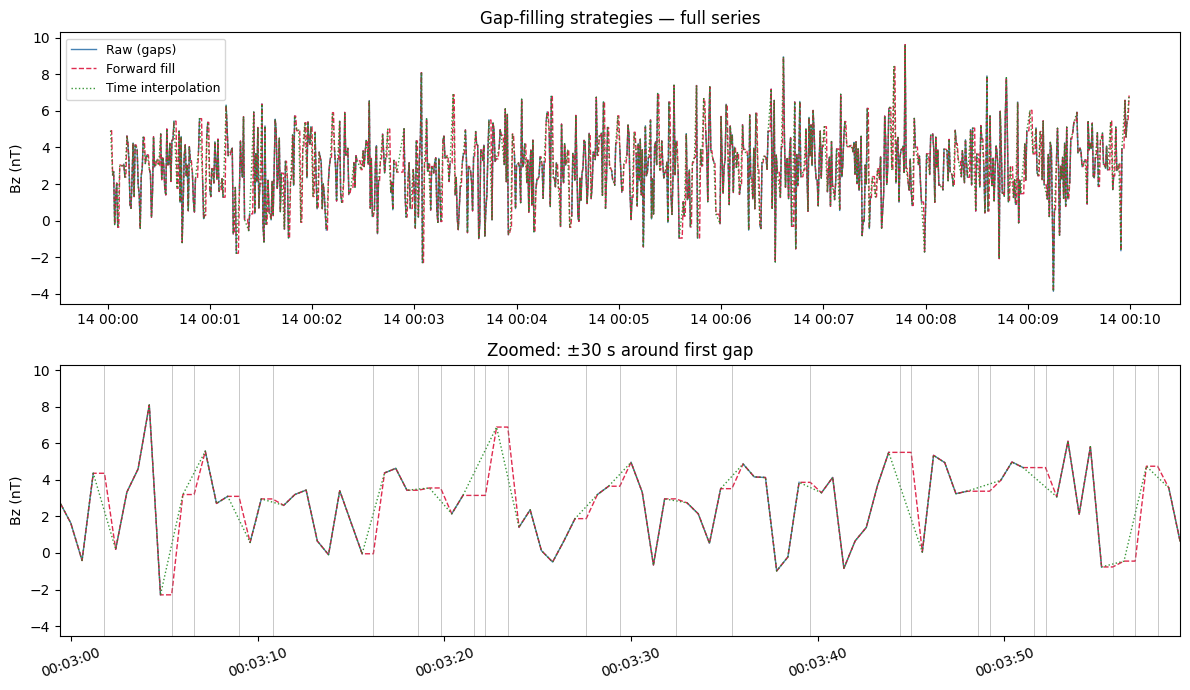

In [23]:
# Derived column: dynamic pressure
m_p = 1.673e-27   # proton mass in kg
df["Pdyn_nPa"] = (
    0.5 * m_p
    * (df["n_cc"] * 1e6)          # cm⁻³ → m⁻³
    * (df["v_km_s"] * 1e3) ** 2  # km/s → m/s
    * 1e9                         # Pa → nPa
)

# Simulate data gaps: randomly set ~5 % of Bz values to NaN
gap_idx = rng.choice(df.index, size=50, replace=False)
df.loc[gap_idx, "Bz_nT"] = np.nan

print(f"NaN count in Bz_nT: {df['Bz_nT'].isna().sum()}")

# Options for handling gaps:
df["Bz_filled"]  = df["Bz_nT"].ffill()             # forward fill
df["Bz_interp"]  = df["Bz_nT"].interpolate("time") # linear time interpolation

# Compare gap-filling strategies visually
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# ── Left: full time series ────────────────────────────────────────────────
for ax in axes:
    ax.plot(df.index, df["Bz_nT"],     label="Raw (gaps)",         lw=1, color="steelblue")
    ax.plot(df.index, df["Bz_filled"], label="Forward fill",       lw=1, alpha=0.9, ls="--", color="crimson")
    ax.plot(df.index, df["Bz_interp"], label="Time interpolation", lw=1, alpha=0.9, ls=":",  color="forestgreen")
    ax.set_ylabel("Bz (nT)")

axes[0].legend(fontsize=9)
axes[0].set_title("Gap-filling strategies — full series")

# ── Right: zoom into a 60-second window around the first gap ─────────────
# Find the first NaN and centre a 60-second window on it
first_gap = df.index[df["Bz_nT"].isna()][100]
zoom_start = first_gap - pd.Timedelta("30s")
zoom_end   = first_gap + pd.Timedelta("30s")
axes[1].set_xlim(zoom_start, zoom_end)

# Mark the gap locations inside the zoom window
gap_times = df.index[df["Bz_nT"].isna()]
gap_times_zoom = gap_times[(gap_times >= zoom_start) & (gap_times <= zoom_end)]
for gt in gap_times_zoom:
    axes[1].axvline(gt, color="grey", lw=0.6, ls="-", alpha=0.5)

axes[1].set_title("Zoomed: ±30 s around first gap")
axes[1].tick_params(axis="x", labelrotation=20)

plt.tight_layout()
plt.show()

### 3.3 Resampling and Rolling Statistics

Time-series analysis often requires comparing data at different cadences (e.g., 600 ms burst data vs. 1-minute survey data) or computing running averages to smooth out noise.

Burst resolution: 1000 points → Survey resolution: 10 points


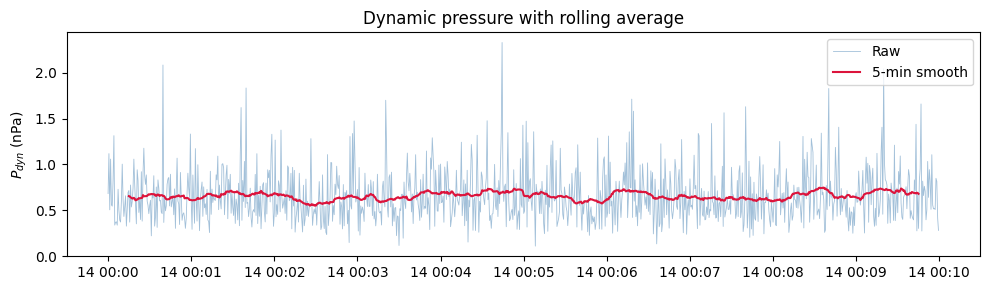

In [24]:
# Resample to 1-minute averages — mimics survey-mode cadence
df_1min = df[["B_mag_nT", "n_cc", "Pdyn_nPa"]].resample("1min").mean()
print(f"Burst resolution: {len(df)} points → Survey resolution: {len(df_1min)} points")

# 5-minute rolling mean on dynamic pressure
df["Pdyn_smooth"] = df["Pdyn_nPa"].rolling(window=50, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df.index, df["Pdyn_nPa"],     lw=0.6, label="Raw", color="steelblue", alpha=0.5)
ax.plot(df.index, df["Pdyn_smooth"],  lw=1.5, label="5-min smooth", color="crimson")
ax.set_ylabel("$P_{dyn}$ (nPa)")
ax.legend()
ax.set_title("Dynamic pressure with rolling average")
plt.tight_layout()
plt.show()

### Exercise 3.1

Using `df`:

1. Add a boolean column `southward` that is `True` when `Bz_interp < 0`.
2. Use `groupby("southward")` to compute the mean dynamic pressure separately for northward and southward IMF intervals. What do you notice?
3. *(Bonus)* Compute the fraction of time the IMF is southward in each 1-minute window and plot it.

In [25]:
# YOUR CODE HERE

---

## Part 4 – scikit-learn

### Why scikit-learn?

scikit-learn provides a consistent, well-documented interface (`fit` / `transform` / `predict`) for the majority of classical ML tasks. We will use it heavily for preprocessing, dimensionality reduction, and baseline models throughout the school.

The **golden rule** in machine learning: fit *only* on training data, then apply to test data. Fitting on the whole dataset before splitting leaks information into your evaluation and produces overly optimistic results.

### 4.1 The Train/Test Split

In [26]:
# Feature matrix and a synthetic binary label
# Label: 1 if the magnetosphere is likely compressed (high Pdyn AND southward Bz)
features = ["B_mag_nT", "n_cc", "v_km_s", "Pdyn_nPa"]
df_clean = df[features].dropna()

X = df_clean.values
y = (
    (df.loc[df_clean.index, "Pdyn_nPa"] > df["Pdyn_nPa"].quantile(0.6))
    & (df.loc[df_clean.index, "Bz_interp"] < 0)
).astype(int).values

print(f"Dataset size: {X.shape}, positive class fraction: {y.mean():.2%}")

# Split chronologically — time series data must NOT be shuffled naively
# (shuffling would let the model peek at future data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")

Dataset size: (1000, 4), positive class fraction: 2.60%
Train: 800 samples | Test: 200 samples


### 4.2 The Pipeline: Scale → Model → Evaluate

ML models are often sensitive to feature scale. A density of 5 cm⁻³ and a speed of 400 km/s live on very different numerical scales — if we feed them raw to a model, the large-valued features dominate.  
`StandardScaler` removes the mean and divides by the standard deviation, putting all features on a common footing.

In [27]:
# 1. Fit the scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learns mean & std from training set
X_test_scaled  = scaler.transform(X_test)        # applies the SAME transformation

# 2. Fit a simple logistic regression classifier
# class_weight='balanced' corrects for imbalanced classes by weighting the loss
# inversely proportional to class frequency — without it, the model may simply
# predict the majority class for every sample.
clf = LogisticRegression(random_state=42, max_iter=500, class_weight="balanced")
clf.fit(X_train_scaled, y_train)

# 3. Evaluate on the held-out test set
# zero_division=0 suppresses the warning that appears when a class has no
# predicted samples (precision is undefined and set to 0 in that case).
y_pred = clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred,
                             target_names=["Not compressed", "Compressed"],
                             zero_division=0))

                precision    recall  f1-score   support

Not compressed       1.00      0.71      0.83       197
    Compressed       0.05      1.00      0.10         3

      accuracy                           0.71       200
     macro avg       0.53      0.86      0.46       200
  weighted avg       0.99      0.71      0.82       200



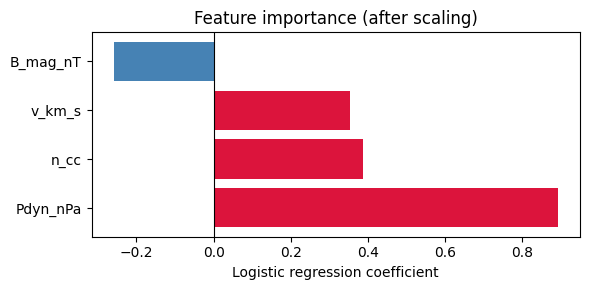

In [28]:
# Inspect the model coefficients — which features matter most?
coef_df = pd.DataFrame(
    {"feature": features, "coefficient": clf.coef_[0]}
).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
colors = ["crimson" if c > 0 else "steelblue" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Feature importance (after scaling)")
plt.tight_layout()
plt.show()

### What did the model learn?

Positive coefficients push the model toward predicting "compressed"; negative ones push toward "not compressed". Because we scaled the features first, the magnitudes are directly comparable.

> **Physical sanity check:** Does the sign of each coefficient make physical sense given how we defined the label?

### Exercise 4.1

scikit-learn makes it easy to swap in a different model with the same interface.

1. Replace `LogisticRegression` with `sklearn.ensemble.RandomForestClassifier(n_estimators=100, random_state=42)`.
2. Does scaling matter for a random forest? (Hint: check the scikit-learn docs — tree-based methods are scale-invariant.)
3. Compare the classification reports. Which model does better, and why might that be?

In [29]:
from sklearn.ensemble import RandomForestClassifier

# YOUR CODE HERE

---

## Part 5 – A Note on xarray

### The Problem xarray Solves

Consider a THEMIS particle spectrogram: it is a 2-D array where one axis is time (thousands of timestamps) and the other is energy channel (dozens of bins). With NumPy you store it as `data[time_idx, energy_idx]` and carry two separate arrays for the axis values.  
Now add a third axis for pitch angle, a fourth for spacecraft component, and you are keeping track of four axis arrays separately, remembering which axis is which, and hoping nothing gets transposed silently.

**xarray attaches coordinate labels directly to the array axes**, so you index by physical meaning rather than by integer position. It also carries metadata (units, long_name, mission) alongside the data — exactly what CDF and NetCDF files already store. xarray reads those formats natively.

### 5.1 Creating an xarray DataArray

In [30]:
# Simulate a particle energy spectrogram  (time × energy)
n_times    = 200
energies   = np.array([10, 20, 50, 100, 200, 500, 1000, 2000])  # eV
spec_times = pd.date_range("2017-11-14 01:00", periods=n_times, freq="3s")

# Synthetic differential energy flux (higher at low energies, modulated in time)
flux = np.outer(
    1 + 0.5 * np.sin(np.linspace(0, 4 * np.pi, n_times)),   # time modulation
    energies**(-1.5) * 1e8                                   # power-law energy spectrum
)
flux += rng.exponential(scale=flux * 0.1)  # add noise

# Wrap in a DataArray with named coordinates and metadata
da = xr.DataArray(
    data=flux,
    dims=["time", "energy_eV"],
    coords={"time": spec_times, "energy_eV": energies},
    name="DEF",
    attrs={
        "long_name": "Differential Energy Flux",
        "units": "eV cm⁻² s⁻¹ sr⁻¹ eV⁻¹",
        "spacecraft": "THEMIS-A",
        "instrument": "ESA"
    }
)

print(da)

<xarray.DataArray 'DEF' (time: 200, energy_eV: 8)> Size: 13kB
array([[4.15694846e+06, 1.18375449e+06, 2.95065920e+05, ...,
        1.01826120e+04, 3.16806480e+03, 1.13031298e+03],
       [3.29193724e+06, 1.50547032e+06, 3.33314070e+05, ...,
        1.04161034e+04, 4.53941549e+03, 1.15878243e+03],
       [4.05352853e+06, 1.43350742e+06, 3.23612711e+05, ...,
        9.55958307e+03, 4.32593451e+03, 1.25324235e+03],
       ...,
       [3.95556522e+06, 1.11506348e+06, 2.68478178e+05, ...,
        8.57731232e+03, 3.05625936e+03, 1.22533526e+03],
       [3.11827610e+06, 1.09661885e+06, 3.02107322e+05, ...,
        9.48917180e+03, 3.51270172e+03, 1.19891060e+03],
       [4.13538290e+06, 1.13281852e+06, 2.86193011e+05, ...,
        1.03859395e+04, 3.18857352e+03, 1.46466926e+03]], shape=(200, 8))
Coordinates:
  * time       (time) datetime64[us] 2kB 2017-11-14T01:00:00 ... 2017-11-14T0...
  * energy_eV  (energy_eV) int64 64B 10 20 50 100 200 500 1000 2000
Attributes:
    long_name:   Differenti

Notice how the printed representation shows both the shape *and* the coordinate ranges — you immediately know what you are looking at without consulting a separate readme file.

### 5.2 Label-Based Indexing and Reduction

1-minute resampled shape: (10, 8)


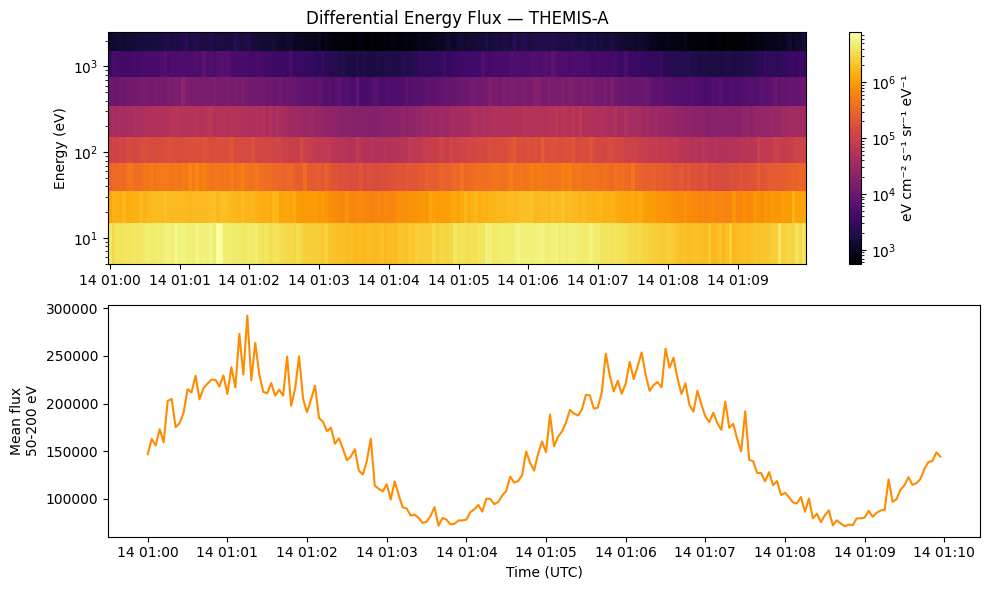

In [31]:
# Select by coordinate value, not by integer index
flux_100eV = da.sel(energy_eV=100)           # exact match
flux_50_200 = da.sel(energy_eV=slice(50, 200))  # range

# Integrate over the 50-200 eV range (energy-weighted mean)
flux_integrated = flux_50_200.mean(dim="energy_eV")

# Resample to 1-minute averages — same API as Pandas
flux_1min = da.resample(time="1min").mean()
print("1-minute resampled shape:", flux_1min.shape)

# Plot the spectrogram
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Log-scale colour map for flux
import matplotlib.colors as mcolors
pcm = axes[0].pcolormesh(
    da.time.values, da.energy_eV.values, da.values.T,
    norm=mcolors.LogNorm(), cmap="inferno", shading="auto"
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Energy (eV)")
axes[0].set_title(f"{da.attrs['long_name']} — {da.attrs['spacecraft']}")
plt.colorbar(pcm, ax=axes[0], label=da.attrs["units"])

axes[1].plot(da.time.values, flux_integrated, color="darkorange")
axes[1].set_ylabel("Mean flux\n50-200 eV")
axes[1].set_xlabel("Time (UTC)")

plt.tight_layout()
plt.show()

### 5.3 Datasets: Multiple Variables in One Object

A `Dataset` is a dictionary of `DataArray` objects that share coordinates — analogous to a Pandas DataFrame, but for N-dimensional data.

In [32]:
# Combine the particle flux and the magnetic field into one Dataset
B_da = xr.DataArray(
    data=B[:n_times],                           # first 200 samples
    dims=["time", "component"],
    coords={"time": spec_times, "component": ["Bx", "By", "Bz"]},
    attrs={"units": "nT"}
)

ds = xr.Dataset({"DEF": da, "B_field": B_da})
print(ds)

# Access like a dictionary
print("\nData variables:", list(ds.data_vars))
print("Bz at first timestamp:", ds["B_field"].sel(component="Bz").isel(time=0).item(), "nT")

<xarray.Dataset> Size: 19kB
Dimensions:    (time: 200, energy_eV: 8, component: 3)
Coordinates:
  * time       (time) datetime64[us] 2kB 2017-11-14T01:00:00 ... 2017-11-14T0...
  * energy_eV  (energy_eV) int64 64B 10 20 50 100 200 500 1000 2000
  * component  (component) <U2 24B 'Bx' 'By' 'Bz'
Data variables:
    DEF        (time, energy_eV) float64 13kB 4.157e+06 1.184e+06 ... 1.465e+03
    B_field    (time, component) float64 5kB 10.61 -6.667 4.199 ... -9.098 5.131

Data variables: ['DEF', 'B_field']
Bz at first timestamp: 4.198532036855746 nT


### 5.4 Reading Real Data

xarray reads NetCDF4 and CDF files directly. CDF is the standard format for MMS, Cluster, and many other missions. The workflow in later notebooks will look like:

```python
import cdflib

# After downloading from CDAWeb:
cdf = cdflib.CDF("mms1_fgm_brst_l2_20171114_v5.130.0.cdf")
epoch = cdflib.cdfepoch.to_datetime(cdf["Epoch"])
B_gsm = cdf["mms1_fgm_b_gsm_brst_l2"]          # shape (N, 4): Bx,By,Bz,|B|

da_B = xr.DataArray(
    data=B_gsm[:, :3],
    dims=["time", "component"],
    coords={"time": epoch, "component": ["Bx", "By", "Bz"]},
    attrs={"units": "nT", "coord_sys": "GSM"}
)
```

You do not need to run this cell now; we will work through real data access on Wednesday.

### Exercise 5.1

Using the `ds` Dataset defined above:

1. Select only the first 60 seconds of both variables using `.sel(time=...)` with a `slice`.
2. Compute the correlation between `|B|` (the magnitude of `B_field`) and the mean particle flux integrated over all energy channels. Does a stronger magnetic field correspond to higher or lower flux in your simulated data?
3. *(Bonus)* Save the Dataset to a NetCDF file with `ds.to_netcdf("test_output.nc")` and reload it with `xr.open_dataset("test_output.nc")`. Check that all attributes survive the round-trip.

In [33]:
# YOUR CODE HERE

---

## Summary

| Tool | Key idea | When to use it |
|------|----------|----------------|
| **Python** | Expressive, readable logic | Glue, configuration, data catalogues |
| **NumPy** | Vectorised array maths | Any numerical computation on homogeneous data |
| **Pandas** | Labelled tables with time-series superpowers | Tabular data, gap-handling, resampling |
| **scikit-learn** | Consistent fit/transform/predict API | Preprocessing, classical ML, evaluation |
| **xarray** | Labelled N-D arrays with metadata | Multi-dimensional mission data, CDF/NetCDF I/O |

### Things that can go wrong (keep these in mind all week)

- **Scale mismatch**: Always scale features before distance-sensitive models (k-NN, SVM, neural nets).
- **Data leakage**: Never fit a scaler or model on the test set. For time-series, never shuffle before splitting.
- **NaN propagation**: NumPy operations silently propagate `NaN`; use `np.nanmean` / `df.dropna()` deliberately.
- **Unit errors**: xarray `attrs` are your friend — carry units through the computation.

### Further Reading

- NumPy documentation: https://numpy.org/doc/stable/
- Pandas documentation: https://pandas.pydata.org/docs/
- scikit-learn user guide: https://scikit-learn.org/stable/user_guide.html
- xarray tutorials: https://tutorial.xarray.dev/
